In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import geopandas as gpd
from verification.val_db import (get_finalized_validation_datasets,
                                 read_validation_dataset,
                                 get_val_s3_path
                                )

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import numpy as np
from tqdm import tqdm
import rasterio
from matplotlib.colors import ListedColormap
from shapely.geometry import box
from rasterio.plot import show
from pathlib import Path
from verification.rio_tools import get_geopandas_features_from_array
import pandas as pd
import sklearn.metrics
import json
from verification.hls import get_hls_urls

This index is just relative to the finalized datasets.

In [6]:
PLANET_ID = '20211011_155455_52_2262' #'20211002_155415_1009'
EQUAL_SAMPLING = True  # if false currently uses validation labels to determine size of each class sample
TOTAL_PIXELS_PER_SAMPLE = 500
NUMBER_OF_RANDOM_SAMPLES = 100  # aka number of trials
SAMPLE_FROM_DSWX = False # either sample from validation data or dswx (note this does not impact class sizes)
USE_ENTIRE_IMAGE = False # if True, random sampling and trials is moot and just directly samples from entire image
WITH_REPLACEMENT = False # whether to replace samples - will ensure equality if present, untested
CONFIDENCE_MINIMUM = 70 # at least confidence with this threshold

# Saving data for assessments

In [7]:
token_samples = f'{NUMBER_OF_RANDOM_SAMPLES}-trials'
if USE_ENTIRE_IMAGE:
    toke_samples = 'entire_image_used_'
token_conf = f'_conf-geq-{CONFIDENCE_MINIMUM}'
token_class_sample = '_sample-from-dswx' if SAMPLE_FROM_DSWX else 'sample-from-val'

assessment_dir_name = token_samples + token_conf + token_class_sample
assessment_dir_name

'100-trials_conf-geq-70sample-from-val'

In [8]:
out_dir = Path(f'out/assessment_data/{assessment_dir_name}') 
out_dir.mkdir(exist_ok=True, parents=True)
out_dir

PosixPath('out/assessment_data/100-trials_conf-geq-70sample-from-val')

# Table of Finalized Data

In [9]:
df = get_finalized_validation_datasets()
df.head()

,bucket,calc_type,calculated_by,image_calc_name,image_name,notes,oversight_level,previous_name,processing_level,public,reviewed_by,s3_keys,upload_date,version,water_strata,water_stratum,geometry
0,opera-calval-database-dswx,Review,Charlie Marshak,20210903_150800_60_2458_classification_v2,20210903_150800_60_2458,Previous(Previous((CM): Used a NDWI threshold ...,None,20210903_150800_60_2458_classification_v1,Final,True,Alexander Handwerger,data/site/4_21/image/20210903_150800_60_2458/i...,20220930_152559,2.0,NaN,3.0,"POLYGON ((-71.87051 55.11002, -71.87051 55.166..."
1,opera-calval-database-dswx,Review,Charlie Marshak,20210903_152641_60_105c_classification_v2,20210903_152641_60_105c,Previous(This is water with lots of boalders p...,None,20210903_152641_60_105c_classification_v1.0,Final,True,Matthew Bonnema,data/site/4_11/image/20210903_152641_60_105c/i...,20221019_151359,2.0,NaN,3.0,"POLYGON ((-69.17307 54.40592, -69.17307 54.460..."
2,opera-calval-database-dswx,Review,Matthew Bonnema,20210904_093422_44_1065_classification_v1,20210904_093422_44_1065,Previous(Only water is a small pond near cente...,None,20210904_093422_44_1065_classification_v0,Final,True,Simran Sangha,data/site/1_31/image/20210904_093422_44_1065/i...,20221028_164450,1.0,NaN,1.0,"POLYGON ((17.28244 -29.97141, 17.28244 -29.916..."
3,opera-calval-database-dswx,Review,Alexander Handwerger,20210906_101112_28_225a_classification_v1,20210906_101112_28_225a,Previous(Supervised Classification using Semia...,None,20210906_101112_28_225a_classification_v0,Final,True,Charlie Marshak,data/site/3_28/image/20210906_101112_28_225a/i...,20220929_144718,1.0,NaN,2.0,"POLYGON ((-0.04389 43.05233, -0.04389 43.16776..."
4,opera-calval-database-dswx,Review,Charlie Marshak,20210909_000649_94_222b_classification_v1,20210909_000649_94_222b,Previous((CM): Looked at RGB and false color b...,None,20210909_000649_94_222b_classification_v0,Final,True,Alexander Handwerger,data/site/1_37/image/20210909_000649_94_222b/i...,20221027_162451,1.0,NaN,1.0,"POLYGON ((138.25959 -30.32811, 138.25959 -30.2..."


In [10]:
f'Currently, there are {df.shape[0]} finalized datasets'

'Currently, there are 52 finalized datasets'

# Read a Validation Dataset

In [11]:
X_val, p_val = read_validation_dataset(PLANET_ID)
p_val

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 255.0, 'width': 2001, 'height': 2000, 'count': 1, 'crs': CRS.from_epsg(32615), 'transform': Affine(3.0, 0.0, 772092.0,
       0.0, -3.0, 1805622.0), 'blockysize': 4, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}

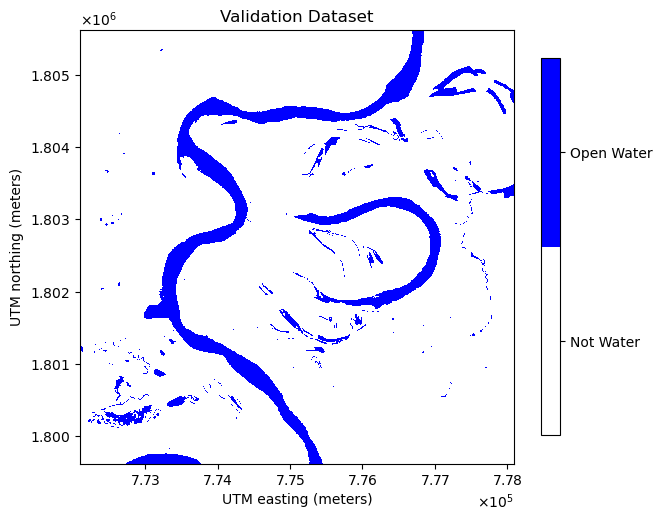

In [12]:
Y = X_val.astype(float)
Y[Y == 255] = np.nan

fontSize=10
fig, ax=plt.subplots(figsize=(7,7))
cmap = ListedColormap(['white', 'blue'])
im=ax.imshow(Y, interpolation='none',cmap=cmap,vmin=0,vmax=1)
show(Y, interpolation='none',cmap=cmap,vmin=0,vmax=1,transform=p_val['transform'],ax=ax)
cbar = fig.colorbar(im, ax=ax,shrink=0.7,ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['Not Water', 'Open Water']);  # vertically oriented colorbar
plt.xlabel('UTM easting (meters)',fontsize=fontSize)
plt.ylabel('UTM northing (meters)',fontsize=fontSize)
plt.xticks(fontsize = fontSize)
plt.yticks(fontsize = fontSize)
ax.set_title('Validation Dataset');
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)

In [13]:
plt.close('all')

# Load Local Validation Table

In [14]:
df_validation_table = pd.read_csv('validation_table_data.csv')
df_validation_table.head()

,planet_id,hls_id,dswx_urls
0,20210903_150800_60_2458,HLS.L30.T18UXG.2021245T154154.v2.0,https://opera-pst-rs-pop1.s3.us-west-2.amazona...
1,20210903_152641_60_105c,HLS.S30.T19UDA.2021245T154911.v2.0,https://opera-pst-rs-pop1.s3.us-west-2.amazona...
2,20210904_093422_44_1065,HLS.S30.T33JYG.2021248T082559.v2.0,https://opera-pst-rs-pop1.s3.us-west-2.amazona...
3,20210906_101112_28_225a,HLS.S30.T30TYN.2021248T105621.v2.0,https://opera-pst-rs-pop1.s3.us-west-2.amazona...
4,20210909_000649_94_222b,HLS.L30.T54JTM.2021251T003848.v2.0,https://opera-pst-rs-pop1.s3.us-west-2.amazona...


# Get Associated HLS Id

In [15]:
HLS_ID = df_validation_table[df_validation_table.planet_id == PLANET_ID].hls_id.iloc[0]
HLS_ID

'HLS.S30.T15QYU.2021284T162221.v2.0'

# Get DSWx Products

In [16]:
dswx_urls = df_validation_table[df_validation_table.planet_id == PLANET_ID].dswx_urls.iloc[0].split(',')
dswx_urls

['https://opera-pst-rs-pop1.s3.us-west-2.amazonaws.com/products/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0_B01_WTR.tiff',
 'https://opera-pst-rs-pop1.s3.us-west-2.amazonaws.com/products/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0_B02_BWTR.tiff',
 'https://opera-pst-rs-pop1.s3.us-west-2.amazonaws.com/products/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0_B03_CONF.tiff',
 'https://opera-pst-rs-pop1.s3.us-west-2.amazonaws.com/products/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0_B04_DIAG.tiff',
 'https://opera-pst-rs-pop1.s3.us-west-2.amazonaws.com/products/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_2022102

In [17]:
with rasterio.open(dswx_urls[0]) as ds:
    X_dswx = ds.read(1)
    p_dswx = ds.profile
    crs_dswx = ds.crs
    colormap = ds.colormap(1)
    dswx_crs = ds.crs

In [18]:
with rasterio.open(dswx_urls[2]) as ds:
    conf_dsx = ds.read(1)
    conf_colormap = ds.colormap(1)

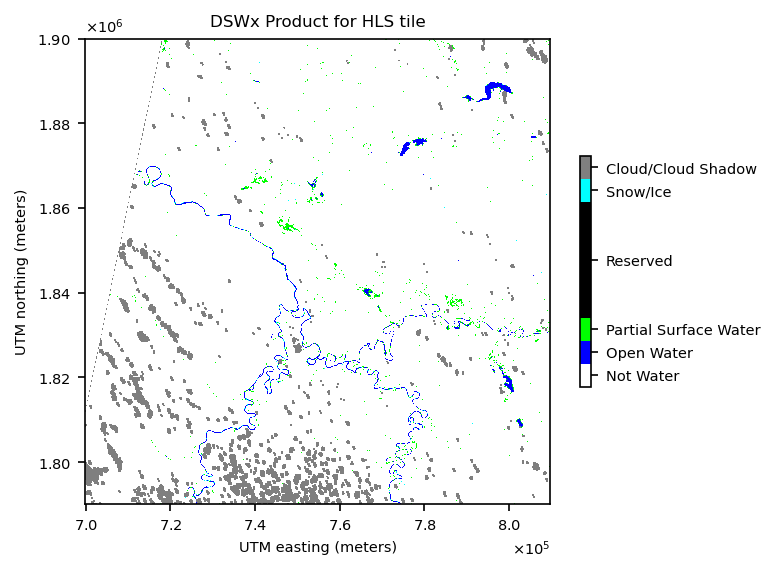

In [19]:
fontSize=7
fontSizeTitle=8
fig, ax = plt.subplots(dpi=150,figsize=(5,5))
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
im_dswx=ax.imshow(X_dswx, interpolation='none',cmap=cmap,vmin=0,vmax=255)
show(X_dswx, interpolation='none',cmap=cmap,vmin=0,vmax=255,transform=p_dswx['transform'],ax=ax)
cbar=fig.colorbar(im_dswx,ax=ax,shrink=0.4,ticks=[0.5, 1.5, 2.5,5.5,8.5, 9.5])
cbar.set_ticklabels(['Not Water', 'Open Water','Partial Surface Water','Reserved','Snow/Ice','Cloud/Cloud Shadow'],fontsize=fontSize)   
cbar.ax.set_ylim(0,10)
plt.xlabel('UTM easting (meters)',fontsize=fontSize)
plt.ylabel('UTM northing (meters)',fontsize=fontSize)
plt.xticks(fontsize = fontSize)
plt.yticks(fontsize = fontSize)
ax.set_title('DSWx Product for HLS tile',fontsize=fontSizeTitle);
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)

In [20]:
plt.close('all')

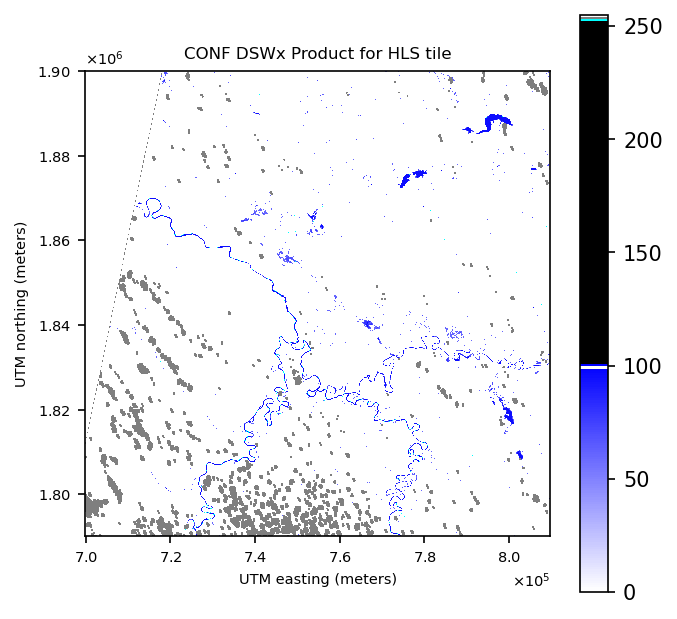

In [21]:
fontSize=7
fontSizeTitle=8
fig, ax = plt.subplots(dpi=150,figsize=(5,5))
cmap = ListedColormap([np.array(conf_colormap[key]) / 255 for key in range(256)])
im_dswx=ax.imshow(conf_dsx, 
                  interpolation='none',
                  cmap=cmap,
                  vmin=0,
                  vmax=255)
show(conf_dsx, 
     interpolation='none',
     cmap=cmap,
     vmin=0,vmax=255,
     transform=p_dswx['transform'],
     ax=ax)
cbar=fig.colorbar(im_dswx,ax=ax)

plt.xlabel('UTM easting (meters)',fontsize=fontSize)
plt.ylabel('UTM northing (meters)',fontsize=fontSize)
plt.xticks(fontsize = fontSize)
plt.yticks(fontsize = fontSize)
ax.set_title('CONF DSWx Product for HLS tile',fontsize=fontSizeTitle);
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)

In [22]:
plt.close('all')

# Compare Extents

Inspect the DSWx Subset and it's corresponding Validation Dataset

In [23]:
val_url = get_val_s3_path(PLANET_ID)
with rasterio.open(val_url) as ds:
    val_bounds = list(ds.bounds)
    val_crs = ds.crs

The two datasets are frequently in the same CRS. Just in case, we reproject to DSWx projection.

In [24]:
df_val_bounds = gpd.GeoDataFrame(geometry=[box(*val_bounds).buffer(60)],
                                 crs=val_crs)
df_val_bounds = df_val_bounds.to_crs(dswx_crs)
df_val_bounds

,geometry
0,"POLYGON ((778095.000 1799562.000, 772092.000 1..."


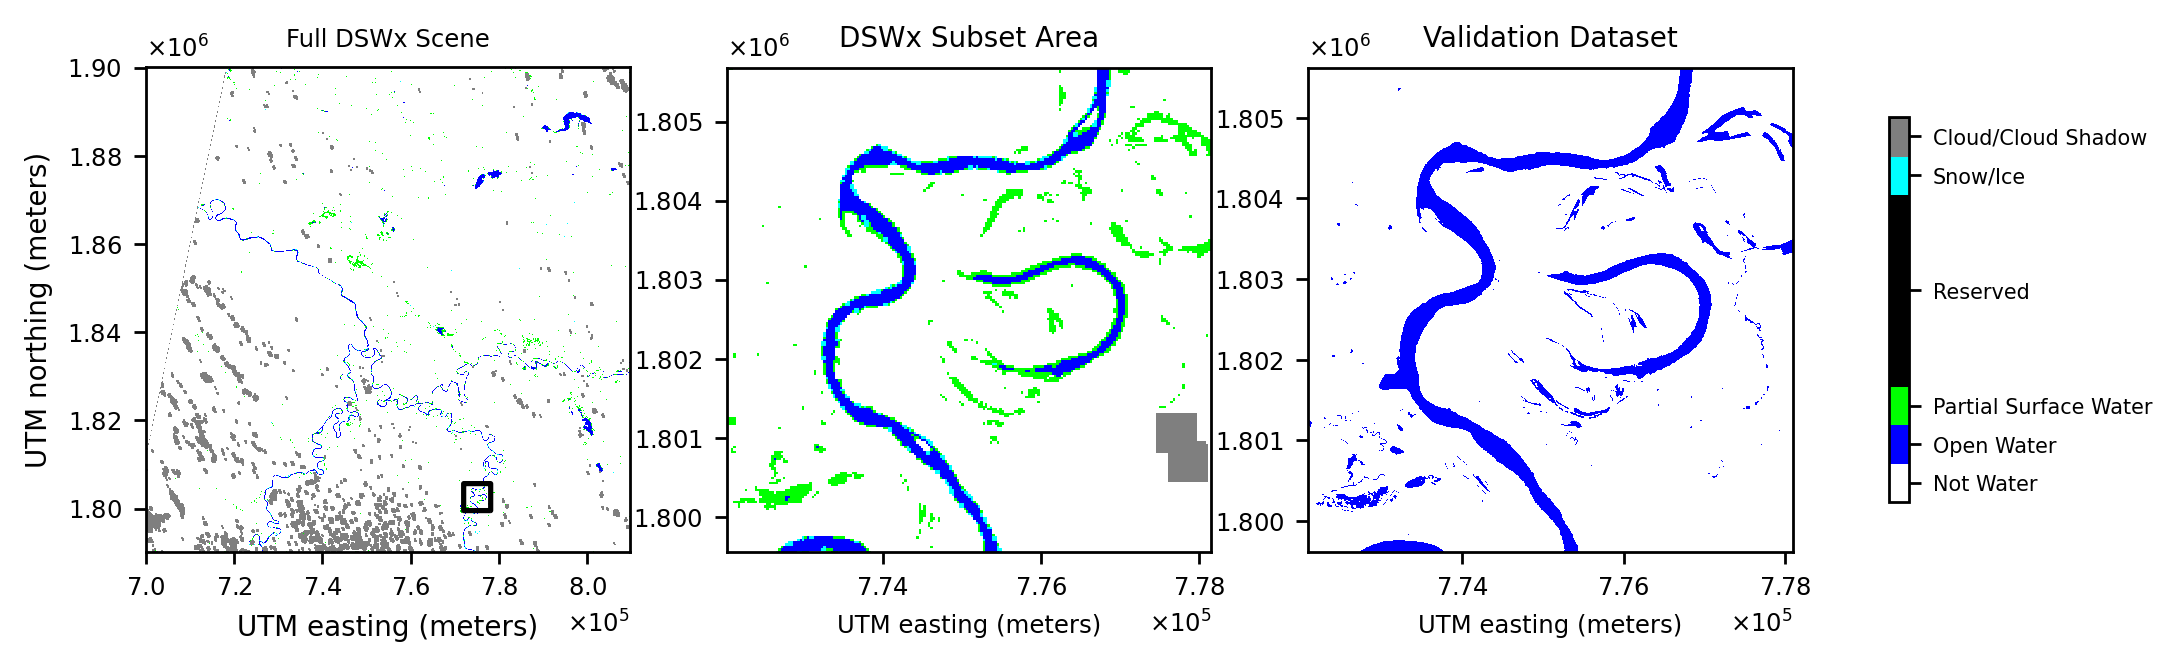

In [110]:
fontSize=7
fontSizeTitles=8
fig, ax = plt.subplots(1, 3, dpi=250, figsize=(10, 10))
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])

show(X_dswx, cmap=cmap, transform=p_dswx['transform'], vmin=0, vmax=255, interpolation='none', ax=ax[0])
df_val_bounds.to_crs(crs_dswx).boundary.plot(ax=ax[0], color='black')
ax[0].set_title('Full DSWx Scene',fontsize=fontSize)
ax[0].set_xlabel('UTM easting (meters)',fontsize=fontSizeTitles)
ax[0].set_ylabel('UTM northing (meters)',fontsize=fontSizeTitles)
ax[0].ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax[0].tick_params(axis='both', which='major', labelsize=fontSize)
ax[0].yaxis.get_offset_text().set_fontsize(fontSize)
ax[0].xaxis.get_offset_text().set_fontsize(fontSize)

data_dswx = show(X_dswx, cmap=cmap, 
                 transform=p_dswx['transform'], 
                 vmin=0,vmax=255, 
                 interpolation='none', 
                 ax=ax[1])
im_dswx = data_dswx.get_images()[0]
val_bounds_dswx = df_val_bounds.to_crs(crs_dswx).total_bounds
ax[1].set_xlim(val_bounds_dswx[0], val_bounds_dswx[2])
ax[1].set_ylim(val_bounds_dswx[1], val_bounds_dswx[3])
ax[1].set_title('DSWx Subset Area',fontsize=fontSizeTitles)
ax[1].set_xlabel('UTM easting (meters)',fontsize=fontSize)
ax[1].ticklabel_format(axis='both', style='scientific',scilimits=(0,0), useOffset=False, useMathText=True)
ax[1].tick_params(axis='both', which='major', labelsize=fontSize)
ax[1].yaxis.get_offset_text().set_fontsize(fontSize)
ax[1].xaxis.get_offset_text().set_fontsize(fontSize)

show(X_val, transform=p_val['transform'], ax=ax[2], interpolation='none', cmap=cmap, vmin=0, vmax=255)
ax[2].set_title('Validation Dataset',fontsize=fontSizeTitles)
ax[2].set_xlabel('UTM easting (meters)',fontsize=fontSize)
ax[2].ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax[2].tick_params(axis='both', which='major', labelsize=fontSize)
ax[2].yaxis.get_offset_text().set_fontsize(fontSize)
ax[2].xaxis.get_offset_text().set_fontsize(fontSize)

cbar=fig.colorbar(im_dswx,
                  ax=ax,
                  ticks=[0.5, 1.5, 2.5,5.5,8.5, 9.5],
                  shrink=0.2,
                  orientation='vertical',
                  fraction=0.1,
                  pad=.05)
cbar.set_ticklabels(['Not Water', 
                     'Open Water',
                     'Partial Surface Water',
                     'Reserved',
                     'Snow/Ice',
                     'Cloud/Cloud Shadow'],
                    rotation=0)   
cbar.ax.tick_params(labelsize=6)
cbar.ax.set_ylim(0,10);

In [32]:
plt.close('all')

# Crop Datasets

In [33]:
from dem_stitcher.rio_window import read_raster_from_window

In [34]:
X_dswx_c, p_dswx_c = read_raster_from_window(dswx_urls[0], 
                                             list(df_val_bounds.total_bounds), 
                                             df_val_bounds.crs)

In [35]:
conf_dswx_c, _ = read_raster_from_window(dswx_urls[2], 
                                         list(df_val_bounds.total_bounds), 
                                         df_val_bounds.crs)

# Exclude Small Water bodies in validation

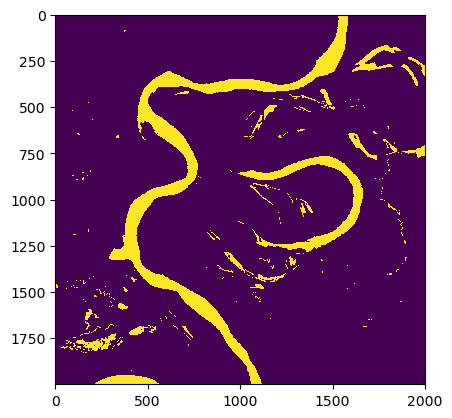

In [36]:
from skimage.measure import label, regionprops
from skimage.color import label2rgb

X_val_water_only = (X_val == 1).astype(int)
plt.imshow(X_val_water_only, interpolation='none')

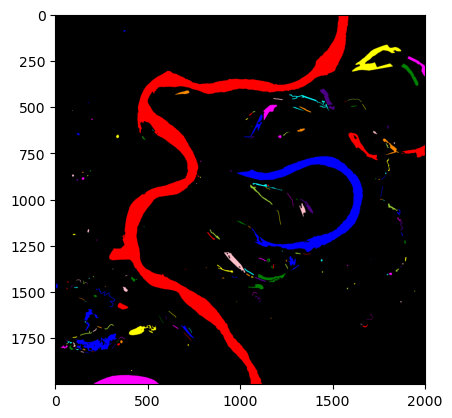

In [37]:
water_labels = label(X_val_water_only, connectivity=2)
water_labels_rbg = label2rgb(water_labels)
plt.imshow(water_labels_rbg)

In [38]:
props = regionprops(water_labels)
props[0].area

217040

In [39]:
for k in range(4):
    print('One way:', (water_labels == (k+1)).sum())
    print('region props: ', props[k].area)

One way: 217040
region props:  217040
One way: 80
region props:  80
One way: 11644
region props:  11644
One way: 2154
region props:  2154


In [40]:
labels_to_exclude = [(k+1) for (k, prop) in enumerate(props) if prop.area <= 3333]
size_mask = np.isin(water_labels, labels_to_exclude)

Text(0.5, 1.0, 'Water bodies to be excluded')

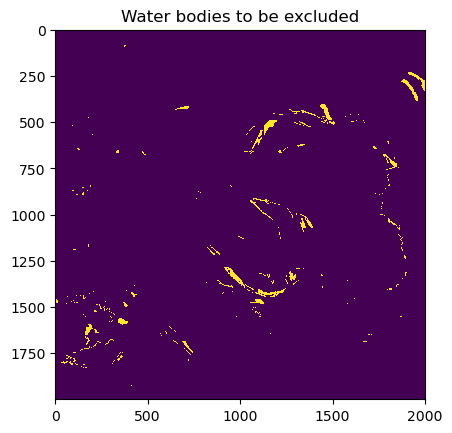

In [41]:
plt.imshow(size_mask, interpolation='none')
plt.title('Water bodies to be excluded')

In [42]:
plt.close('all')

# Resample Validation Dataset to DSWx Product

This extracts a percent open surface water in HLS frame.

In [43]:
from dem_stitcher.rio_tools import reproject_arr_to_match_profile, update_profile_resolution

X_val_temp = X_val.astype('float32')
X_val_temp[(X_val == 10) | (X_val == 255) | size_mask] = np.nan

p_val_temp = p_val.copy()
p_val_temp['dtype'] = 'float32'
p_val_temp['nodata'] = np.nan

p_dswx_c_mod = update_profile_resolution(p_dswx_c, 
                                         p_val['transform'].a)


X_val_per_w_int, p_per_int = reproject_arr_to_match_profile(X_val_temp,
                                                    p_val_temp, 
                                                    p_dswx_c_mod)
X_val_per_w_int = X_val_per_w_int[0, ...]

X_val_per_w, _ = reproject_arr_to_match_profile(X_val_per_w_int,
                                                p_per_int, 
                                                p_dswx_c)
X_val_per_w = X_val_per_w[0, ...]

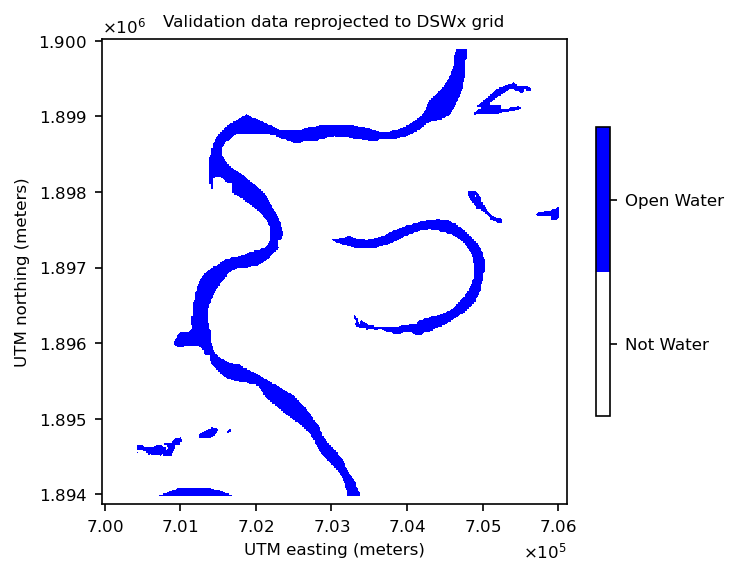

In [44]:
fontSize=8
fig, ax = plt.subplots(dpi=150,figsize=(5, 5))
# cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
cmap = ListedColormap(['white', 'blue'])
im=ax.imshow(X_val_per_w, interpolation='none',cmap=cmap,vmin=np.nanmin(X_val_per_w),vmax=np.nanmax(X_val_per_w))
show(X_val_per_w, vmin=np.nanmin(X_val_per_w),vmax=np.nanmax(X_val_per_w), transform=p_dswx['transform'], ax=ax,cmap=cmap)
cbar=fig.colorbar(im,ax=ax,shrink=0.5,ticks=[0.25, 0.75])
cbar.set_ticklabels(['Not Water', 'Open Water'],fontsize=fontSize)   
cbar.ax.set_ylim(np.nanmin(X_val_per_w),np.nanmax(X_val_per_w))
ax.set_xlabel('UTM easting (meters)',fontsize=fontSize)
ax.set_ylabel('UTM northing (meters)',fontsize=fontSize)
plt.title('Validation data reprojected to DSWx grid',fontsize=fontSize)
plt.xticks(fontsize = fontSize)
plt.yticks(fontsize = fontSize);
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)

In [45]:
plt.close('all')

Convert to DSWx Labels.

In [46]:
X_val_r = np.full(X_val_per_w.shape, 255)

mask = np.isnan(X_val_per_w)

ind_w = (X_val_per_w == 1)
X_val_r[ind_w] = 1

ind_pw = (X_val_per_w >= .5) & (X_val_per_w < 1)
X_val_r[ind_pw] = 2

ind_nw = (X_val_per_w < .5)
X_val_r[ind_nw] = 0

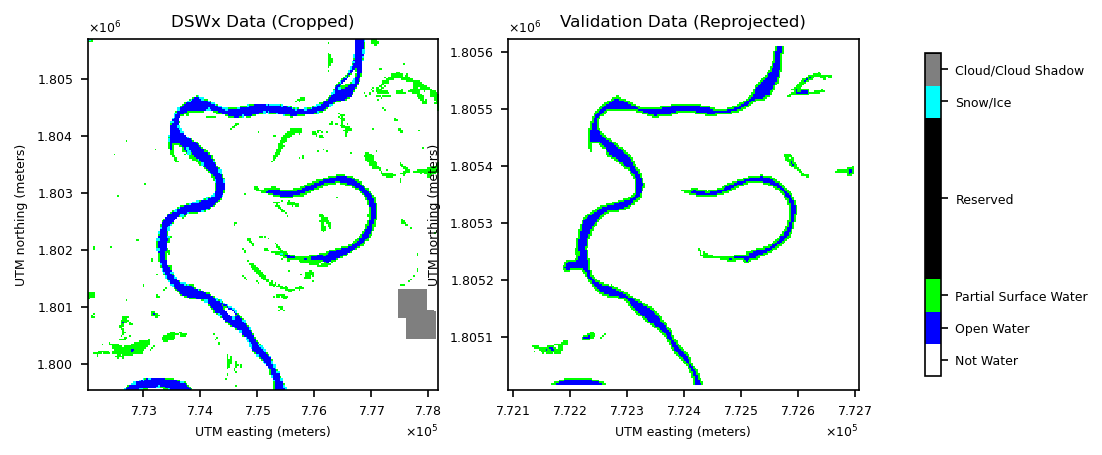

In [118]:
fontSize=6
fig, ax = plt.subplots(1, 2, dpi=150, figsize=(8, 8))
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
im=ax[0].imshow(X_dswx_c, interpolation='none',cmap=cmap,vmin=0,vmax=255)

show(X_dswx_c, cmap=cmap, transform=p_dswx_c['transform'], interpolation='none', ax=ax[0], vmin=0,vmax=255)
ax[0].set_title('DSWx Data (Cropped)',fontsize=8)
ax[0].set_xlabel('UTM easting (meters)',fontsize=fontSize)
ax[0].set_ylabel('UTM northing (meters)',fontsize=fontSize)
ax[0].ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax[0].tick_params(axis='both', which='major', labelsize=fontSize)
ax[0].yaxis.get_offset_text().set_fontsize(fontSize)
ax[0].xaxis.get_offset_text().set_fontsize(fontSize)

show(X_val_r, cmap=cmap, transform=p_val['transform'], interpolation='none',ax=ax[1], vmin=0, vmax=255)
ax[1].set_title('Validation Data (Reprojected)',fontsize=8)
ax[1].set_xlabel('UTM easting (meters)',fontsize=fontSize)
ax[1].set_ylabel('UTM northing (meters)',fontsize=fontSize)

ax[1].ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax[1].tick_params(axis='both', which='major', labelsize=fontSize)
ax[1].yaxis.get_offset_text().set_fontsize(fontSize)
ax[1].xaxis.get_offset_text().set_fontsize(fontSize)

cbar=fig.colorbar(im,
                  ax=ax,ticks=[0.5, 1.5,2.5,5.5,8.5,9.5],
                  shrink=0.35,
                  fraction=.1,
                  orientation='vertical',
                  pad=.071)
cbar.set_ticklabels(['Not Water', 'Open Water','Partial Surface Water','Reserved','Snow/Ice','Cloud/Cloud Shadow'],rotation=0)   
cbar.ax.tick_params(labelsize=fontSize)
cbar.ax.set_ylim(0,10);

In [48]:
plt.close('all')

**Warning**: In many cases, the UTM zone of the validation dataset and the OPERA DSWx product do not match. So despite some of the side-by-side plots that appear parallel, the rotation above can come as surprise. A slight rotation will occur if the below CRS's are different.

In [49]:
print('DSWx CRS: ', p_dswx['crs'])
print('Validation CRS: ', p_val['crs'])

DSWx CRS:  PROJCS["UTM Zone 15, Northern Hemisphere",GEOGCS["Unknown datum based upon the WGS 84 ellipsoid",DATUM["Not_specified_based_on_WGS_84_spheroid",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-93],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Validation CRS:  EPSG:32615


# Save Relevant Rasters for Inspection

In [50]:
dswx_urls[0].split('_B01')[0]

'https://opera-pst-rs-pop1.s3.us-west-2.amazonaws.com/products/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0/OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0'

In [51]:
DSWx_ID = dswx_urls[0].split('_B01')[0].split('/')[-1]
DSWx_ID

'OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_20221026T061819Z_S2A_30_v0.0'

In [52]:
dswx_dir = out_dir / DSWx_ID
dswx_dir.mkdir(exist_ok=True)

In [53]:
p_val_r = p_dswx_c.copy()
p_val_r['dtype'] = np.uint8
p_val_r['nodata'] = 255

with rasterio.open(dswx_dir / f'validation_r_{DSWx_ID}.tif', 'w', **p_val_r) as ds:
    ds.write(X_val_r, 1)
    ds.write_colormap(1, colormap)

In [54]:
p_perc_r = p_dswx_c.copy()
p_perc_r['dtype'] = np.float32
p_perc_r['nodata'] = np.nan

with rasterio.open(dswx_dir / f'percent_r_{DSWx_ID}.tif', 'w', **p_perc_r) as ds:
    ds.write(X_val_per_w, 1)

In [55]:
with rasterio.open(dswx_dir / f'percent_intermediate_{DSWx_ID}.tif', 'w', **p_per_int) as ds:
    ds.write(X_val_per_w_int, 1)

In [56]:
with rasterio.open(dswx_dir / f'{DSWx_ID}.tif', 'w', **p_dswx_c) as ds:
    ds.write(X_dswx_c, 1)
    ds.write_colormap(1, colormap)

In [57]:
with rasterio.open(dswx_dir / f'validation_original_{DSWx_ID}.tif', 'w', **p_val) as ds:
    ds.write(X_val, 1)
    ds.write_colormap(1, colormap)

# Scene-wise stratified sampling

In [58]:
shared_mask = (X_val_r == 255) | ~(np.isin(X_dswx_c, [0, 1, 2]))

if CONFIDENCE_MINIMUM:
    confidence_mask = (conf_dswx_c < CONFIDENCE_MINIMUM)
    shared_mask = (shared_mask | confidence_mask)

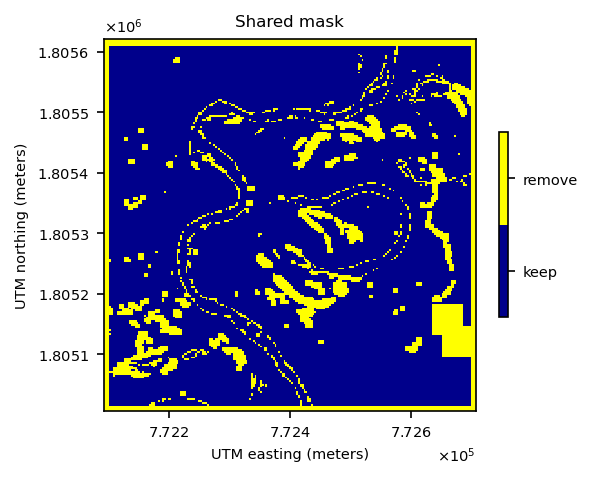

In [59]:

fontSize=7
fig, ax = plt.subplots(dpi=150,figsize=(4, 4))
cmap = ListedColormap(['darkblue', 'yellow'])
im=ax.imshow(shared_mask, interpolation='none',cmap=cmap,vmin=np.nanmin(shared_mask),vmax=np.nanmax(shared_mask))
show(shared_mask, transform=p_val['transform'], interpolation='none', vmin=np.nanmin(shared_mask),vmax=np.nanmax(shared_mask),ax=ax,cmap=cmap)  
cbar=fig.colorbar(im,ax=ax,shrink=0.4,ticks=[0.25, .75])
cbar.set_ticklabels(['keep', 'remove'],fontsize=fontSize)   
cbar.ax.set_ylim(0,1)
ax.set_title('Shared mask',fontsize=8);
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)
plt.xlabel('UTM easting (meters)',fontsize=fontSize)
plt.ylabel('UTM northing (meters)',fontsize=fontSize)
plt.yticks(fontsize=fontSize)
plt.xticks(fontsize=fontSize);

In [60]:
plt.close('all')

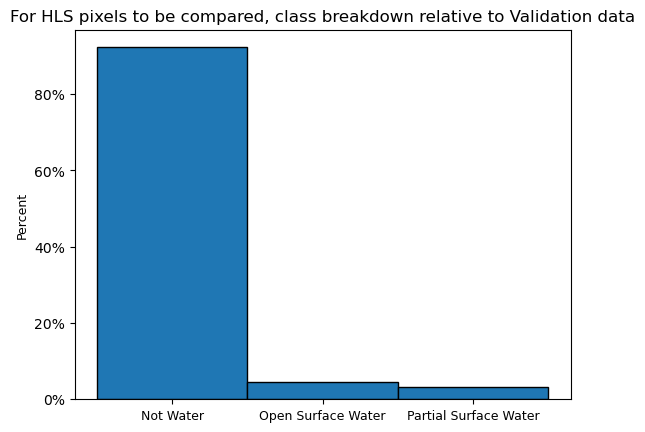

In [61]:
percents, _, _ = plt.hist(X_val_r[~shared_mask], bins=3, range=(0, 3), density=True, edgecolor='black')
plt.xticks(np.arange(0, 3)+.5, ['Not Water', 'Open Surface Water', 'Partial Surface Water'],fontsize=9)
plt.ylabel('Percent',fontsize=9)
plt.title('For HLS pixels to be compared, class breakdown relative to Validation data');
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

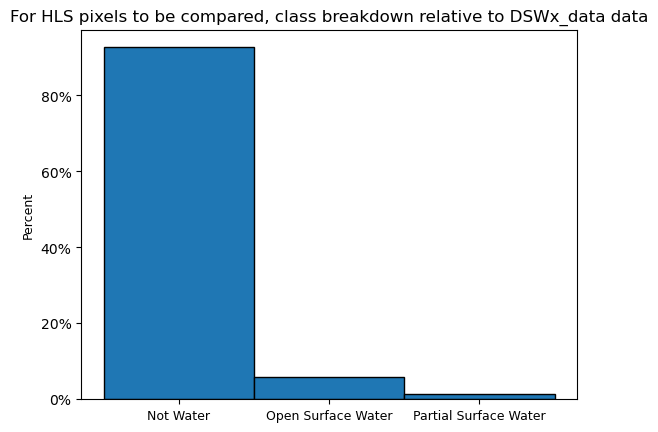

In [62]:
percents_dswx, _, _ = plt.hist(X_dswx_c[~shared_mask], bins=3, range=(0, 3), density=True, edgecolor='black')
plt.xticks(np.arange(0, 3)+.5, ['Not Water', 'Open Surface Water', 'Partial Surface Water'],fontsize=9)
plt.ylabel('Percent',fontsize=9)
plt.title('For HLS pixels to be compared, class breakdown relative to DSWx_data data');
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

In [63]:
plt.close('all')

In [64]:
f'Percents per DSWx class: {percents_dswx}'

'Percents per DSWx class: [0.92694731 0.05953608 0.01351661]'

In [65]:
f'Percents per validation class: {percents}'

'Percents per validation class: [0.92308133 0.04447308 0.03244559]'

In [66]:
sample_size_per_label = [int(np.ceil(percents[label] * TOTAL_PIXELS_PER_SAMPLE)) for label in [0, 1, 2]]
if EQUAL_SAMPLING:
    present_classes = (percents > 0).sum()
    #always multiply by 3 because we have 3 labels
    # sample sizes are modified depending on availability (see cell below)
    sample_size_per_label = [int(np.ceil(TOTAL_PIXELS_PER_SAMPLE / present_classes))] * 3
    
sample_size_per_label

[167, 167, 167]

In [67]:
validation_hls_pixels = X_val_r[~shared_mask]
dswx_hls_pixels = X_dswx_c[~shared_mask]

sample_pixels = dswx_hls_pixels if SAMPLE_FROM_DSWX else validation_hls_pixels

sample_str = 'dswx' if SAMPLE_FROM_DSWX else 'the validation dataset'
f'We are sampling from {sample_str}'

'We are sampling from the validation dataset'

In [68]:
NUMBER_OF_RANDOM_SAMPLES = 100

In [69]:
np.random.seed(0)

# list of lists, 
# each index corresponds to class label 0, 1, 2 and the list will contain
# indices within the flattend array of that label
stratified_selection = [[] for k in range(NUMBER_OF_RANDOM_SAMPLES)] 

for random_sample in range(NUMBER_OF_RANDOM_SAMPLES):
    for label in [0, 1, 2]:
        # Sampling from PRODUCT PIXELS now
        indices = np.argwhere(sample_pixels == label).ravel()

        # Determines if there are enough samples otherwise select the total number of samples available
        subset_size = sample_size_per_label[label]
        if not WITH_REPLACEMENT:
            subset_size = np.minimum(subset_size, len(indices))
            sample_size_per_label[label] = subset_size

        indices_subset = np.random.choice(indices, subset_size, replace=WITH_REPLACEMENT)
        stratified_selection[random_sample].append(indices_subset)
sample_size_per_label

[167, 167, 167]

In [70]:
validation_labels = [[label for label in [0, 1, 2] 
                      for k in range(len(stratified_selection[random_sample][label]))]
                     for j in range(NUMBER_OF_RANDOM_SAMPLES)
                    ]
opera_dswx_labels = [[dswx_label 
                     for label in [0, 1, 2] 
                     for dswx_label in dswx_hls_pixels[stratified_selection[random_sample][label]]]
                     for random_sample in range(NUMBER_OF_RANDOM_SAMPLES)
                    ]
len(validation_labels[0]), len(opera_dswx_labels[0])

(501, 501)

In [71]:
X_samples = np.full(shared_mask.shape, 0)
temp = X_samples[~shared_mask]

k = 1

RANDOM_SAMPLE_FOR_INSPECTION = 0

sample2validation = {}
sample2dswx = {}

for label in [0, 1, 2]:
    for ind in stratified_selection[RANDOM_SAMPLE_FOR_INSPECTION][label]:
        temp[ind] = k
        # ensure we can look up the sample id and find the correct label for the different datasets we compare
        sample2validation[k] = label
        sample2dswx[k] = dswx_hls_pixels[ind]
        k += 1
    
X_samples[~shared_mask] = temp
(X_samples > 0).sum()

501

In [72]:
features = get_geopandas_features_from_array(# Note 8 bits is not enough for 500 points
                                             X_samples.astype(np.int32), 
                                             transform=p_dswx_c['transform'],
                                             mask=(X_samples==0),
                                             label_name='sample_id'
                                            )
df_samples = gpd.GeoDataFrame.from_features(features, 
                                            crs=p_dswx_c['crs'])
df_samples['val_label'] = df_samples['sample_id'].map(lambda label: sample2validation[label])
df_samples['dswx_label'] = df_samples['sample_id'].map(lambda label: sample2dswx[label])

df_samples.head()

,geometry,sample_id,val_label,dswx_label
0,"POLYGON ((773220.000 1805550.000, 773220.000 1...",54.0,0,0
1,"POLYGON ((774750.000 1805550.000, 774750.000 1...",65.0,0,0
2,"POLYGON ((776070.000 1805550.000, 776070.000 1...",10.0,0,0
3,"POLYGON ((776370.000 1805550.000, 776370.000 1...",88.0,0,0
4,"POLYGON ((772770.000 1805520.000, 772770.000 1...",9.0,0,0


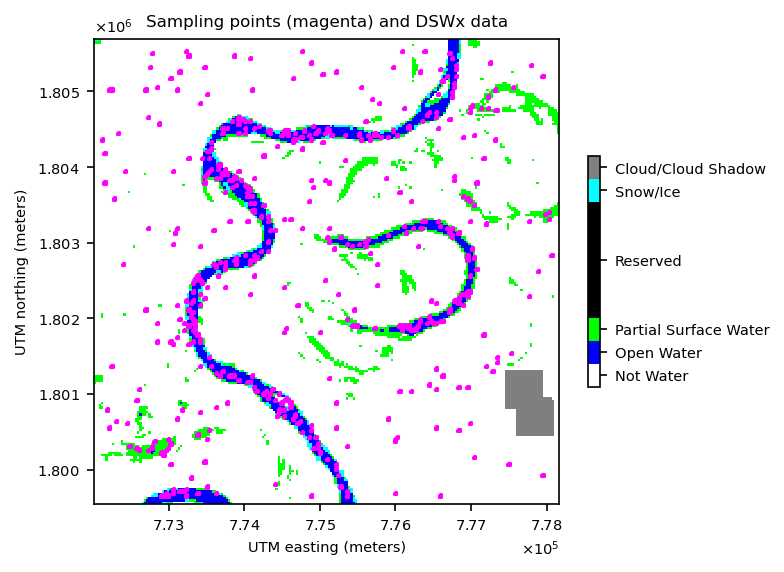

In [73]:
fontSize=7
fontSizeTitle=8
fig, ax = plt.subplots(dpi=150,figsize=(5,5))
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
out = show(X_dswx_c,
     cmap=cmap,
     transform=p_dswx_c['transform'],
     interpolation='none',
     ax=ax,vmin=0,vmax=255)
df_samples.to_crs(p_dswx_c['crs']).boundary.plot(ax=ax, color='magenta',alpha=1)
ax.set_title('Sampling points (magenta) and DSWx data',fontsize=fontSizeTitle)
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
plt.xlabel('UTM easting (meters)',fontsize=fontSize)
plt.ylabel('UTM northing (meters)',fontsize=fontSize)

im_dswx = out.get_images()[0]
cbar=fig.colorbar(im_dswx,ax=ax,shrink=0.4,ticks=[0.5, 1.5, 2.5,5.5,8.5, 9.5])
cbar.set_ticklabels(['Not Water', 'Open Water','Partial Surface Water','Reserved','Snow/Ice','Cloud/Cloud Shadow'],fontsize=fontSize)   
cbar.ax.set_ylim(0,10);
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)
plt.yticks(fontsize=fontSize)
plt.xticks(fontsize=fontSize);

In [74]:
plt.close('all')

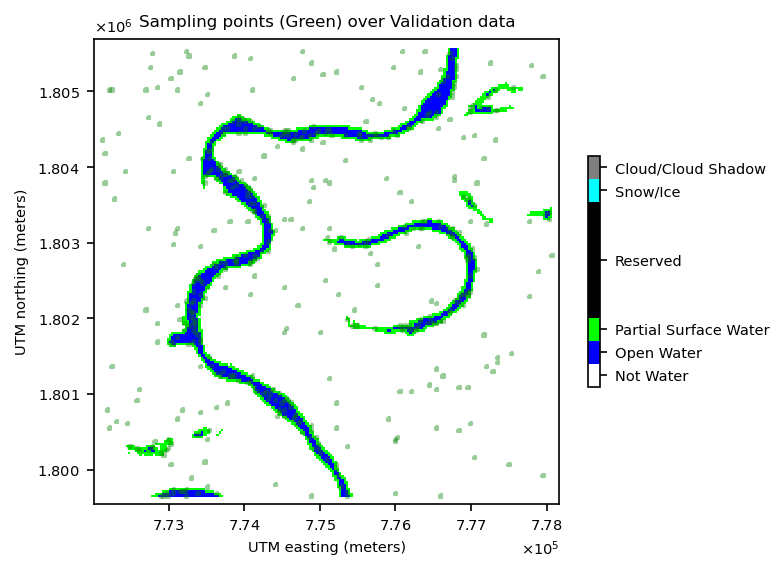

In [78]:
fontSize=7
fontSizeTitle=8
fig, ax = plt.subplots(dpi=150,figsize=(5,5))
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
out = show(X_val_r,cmap=cmap,transform=p_dswx_c['transform'],interpolation='none',ax=ax,vmin=0,vmax=255)
df_samples.to_crs(p_dswx_c['crs']).boundary.plot(ax=ax, color='green',alpha=.4)
ax.set_title('Sampling points (Green) over Validation data',fontsize=fontSizeTitle)
ax.ticklabel_format(axis='both', style='scientific',scilimits=(0,0),useOffset=False,useMathText=True)
plt.xlabel('UTM easting (meters)',fontsize=fontSize)
plt.ylabel('UTM northing (meters)',fontsize=fontSize)

im_dswx = out.get_images()[0]

cbar=fig.colorbar(im_dswx,ax=ax,shrink=0.4,ticks=[0.5, 1.5, 2.5,5.5,8.5, 9.5])
cbar.set_ticklabels(['Not Water', 'Open Water','Partial Surface Water','Reserved','Snow/Ice','Cloud/Cloud Shadow'],fontsize=fontSize)   
cbar.ax.set_ylim(0,10);
ax.yaxis.get_offset_text().set_fontsize(fontSize)
ax.xaxis.get_offset_text().set_fontsize(fontSize)
plt.yticks(fontsize=fontSize)
plt.xticks(fontsize=fontSize);

In [79]:
plt.close('all')

# Accuracy Assessment

In [80]:
class_dict = {0: 'Not Water',
              1: 'Open Surface Water', 
              2: 'Partial Surface Water'}
Target_Names=['Not Water','Open Surface Water','Partial Surface Water']

In [81]:
y_val = np.array([[label for ind in stratified_selection[random_sample] for label in validation_hls_pixels[ind]]
                  for random_sample in range(NUMBER_OF_RANDOM_SAMPLES)
                 ])
y_dswx = np.array([[label  for ind in stratified_selection[random_sample] for label in dswx_hls_pixels[ind]]
                   for random_sample in range(NUMBER_OF_RANDOM_SAMPLES)
                  ])
y_dswx.shape

(100, 501)

We just repeat the last axis so we can still do the same analysis though the aggregation is moot

In [82]:
if USE_ENTIRE_IMAGE:
    y_val = np.repeat(np.array(validation_hls_pixels)[None, :], NUMBER_OF_RANDOM_SAMPLES, axis=0)
    y_dswx = np.repeat(np.array(dswx_hls_pixels)[None,:], NUMBER_OF_RANDOM_SAMPLES, axis=0)
y_dswx.shape

(100, 501)

# Get Metrics for each sample

In [83]:
def get_acc_per_class(y_val, y_dswx):
    acc_per_class = {}
    for c in [0, 1, 2]:
        y_val_temp = y_val.copy()
        y_dswx_temp = y_dswx.copy()

        y_val_temp[y_val_temp != c] = 255
        y_dswx_temp[y_dswx_temp != c] = 255

        acc_per_class[f'acc_per_class.{class_dict[c]}'] = (y_val_temp == y_dswx_temp).sum() / y_dswx.size
    return acc_per_class

def get_prec_recall_score(y_val, y_dswx):
    prec, recall, f1, supp = sklearn.metrics.precision_recall_fscore_support(y_val, y_dswx, labels=[0, 1, 2])
    recall_per_class = {class_dict[label]: recall[label] for label in [0, 1, 2]}
    prec_per_class = {class_dict[label]: prec[label] for label in [0, 1, 2]}
    f1_per_class = {class_dict[label]: f1[label] for label in [0, 1, 2]}
    supp_per_class = {class_dict[label]: int(supp[label]) for label in [0, 1, 2]}
    
    return {
            'precision': prec_per_class,
            'recall': recall_per_class,
            'f1_per_class': f1_per_class,
            'supp_per_class':supp_per_class}

def get_confusion_matrix(y_val, y_dswx):
    y_dswx_str = pd.Series([class_dict[class_id] for class_id in y_dswx], name='OPERA_DSWx')
    y_val_str = pd.Series([class_dict[class_id] for class_id in y_val], name='OPERA_Validation')
    df_conf = pd.crosstab(y_val_str, y_dswx_str)
    df_conf_formatted = df_conf.astype(int)
    
    name = df_conf.index.name
    df_conf_formatted.rename(index={index: f'{index}_{name}' for index in df_conf.index}, inplace=True)
    col_name = df_conf.columns.name
    df_conf_formatted.rename(columns={col: f'{col}_{col_name}' for col in df_conf.columns}, inplace=True)
    return df_conf_formatted

def get_metrics_for_one_sample(y_val, y_dswx):
    total_acc=sklearn.metrics.accuracy_score(y_val, y_dswx)
    
   
    
    pr_dict = get_prec_recall_score(y_val, y_dswx)
    acc_per_class = get_acc_per_class(y_val, y_dswx)
    df_conf_formatted = get_confusion_matrix(y_val, y_dswx)

    return {'total_accuracy': total_acc, 
            'confusion_matrix': df_conf_formatted.to_dict(),
           **pr_dict, **acc_per_class}

In [84]:
from itertools import starmap

data_temp = [(y_val[k], y_dswx[k]) for k in range(NUMBER_OF_RANDOM_SAMPLES)]
metric_data = list(starmap(get_metrics_for_one_sample, tqdm(data_temp)))

100%|███████| 100/100 [00:00<00:00, 161.51it/s]


In [85]:
from pandas import json_normalize
df_all_samples = pd.DataFrame(json_normalize(metric_data))
df_all_samples.head()

,total_accuracy,acc_per_class.Not Water,acc_per_class.Open Surface Water,acc_per_class.Partial Surface Water,confusion_matrix.Not Water_OPERA_DSWx.Not Water_OPERA_Validation,confusion_matrix.Not Water_OPERA_DSWx.Open Surface Water_OPERA_Validation,confusion_matrix.Not Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation,confusion_matrix.Open Surface Water_OPERA_DSWx.Not Water_OPERA_Validation,confusion_matrix.Open Surface Water_OPERA_DSWx.Open Surface Water_OPERA_Validation,confusion_matrix.Open Surface Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation,...,precision.Partial Surface Water,recall.Not Water,recall.Open Surface Water,recall.Partial Surface Water,f1_per_class.Not Water,f1_per_class.Open Surface Water,f1_per_class.Partial Surface Water,supp_per_class.Not Water,supp_per_class.Open Surface Water,supp_per_class.Partial Surface Water
0,0.738523,0.958084,0.768463,0.750499,166,6,14,0,154,103,...,0.862069,0.994012,0.922156,0.299401,0.940510,0.726415,0.444444,167,167,167
1,0.734531,0.934132,0.772455,0.762475,167,14,19,0,147,94,...,0.900000,1.000000,0.880240,0.323353,0.910082,0.720588,0.475771,167,167,167
2,0.756487,0.940120,0.794411,0.778443,167,11,19,0,156,92,...,1.000000,1.000000,0.934132,0.335329,0.917582,0.751807,0.502242,167,167,167
3,0.736527,0.932136,0.786427,0.754491,167,9,25,0,153,93,...,0.907407,1.000000,0.916168,0.293413,0.907609,0.740920,0.443439,167,167,167
4,0.706587,0.936128,0.744511,0.732535,166,13,18,0,148,109,...,0.851064,0.994012,0.886228,0.239521,0.912088,0.698113,0.373832,167,167,167


# Check Output

In [88]:
df_all_samples.to_dict('records')[0]

{'total_accuracy': 0.7385229540918163,
 'acc_per_class.Not Water': 0.9580838323353293,
 'acc_per_class.Open Surface Water': 0.7684630738522954,
 'acc_per_class.Partial Surface Water': 0.7504990019960079,
 'confusion_matrix.Not Water_OPERA_DSWx.Not Water_OPERA_Validation': 166,
 'confusion_matrix.Not Water_OPERA_DSWx.Open Surface Water_OPERA_Validation': 6,
 'confusion_matrix.Not Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation': 14,
 'confusion_matrix.Open Surface Water_OPERA_DSWx.Not Water_OPERA_Validation': 0,
 'confusion_matrix.Open Surface Water_OPERA_DSWx.Open Surface Water_OPERA_Validation': 154,
 'confusion_matrix.Open Surface Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation': 103,
 'confusion_matrix.Partial Surface Water_OPERA_DSWx.Not Water_OPERA_Validation': 1,
 'confusion_matrix.Partial Surface Water_OPERA_DSWx.Open Surface Water_OPERA_Validation': 7,
 'confusion_matrix.Partial Surface Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation': 50,
 'precision.No

# Aggregate

In [89]:
df_sample_stats = df_all_samples.aggregate(['mean', 'std'])

# includes new column with `*.std` and `*.mean`
temp_data = df_sample_stats.to_dict()
df_sample_stats = pd.json_normalize(temp_data)
df_sample_stats['dswx_id'] = DSWx_ID
df_sample_stats['planet_id'] = PLANET_ID
df_sample_stats

,total_accuracy.mean,total_accuracy.std,acc_per_class.Not Water.mean,acc_per_class.Not Water.std,acc_per_class.Open Surface Water.mean,acc_per_class.Open Surface Water.std,acc_per_class.Partial Surface Water.mean,acc_per_class.Partial Surface Water.std,confusion_matrix.Not Water_OPERA_DSWx.Not Water_OPERA_Validation.mean,confusion_matrix.Not Water_OPERA_DSWx.Not Water_OPERA_Validation.std,...,f1_per_class.Partial Surface Water.mean,f1_per_class.Partial Surface Water.std,supp_per_class.Not Water.mean,supp_per_class.Not Water.std,supp_per_class.Open Surface Water.mean,supp_per_class.Open Surface Water.std,supp_per_class.Partial Surface Water.mean,supp_per_class.Partial Surface Water.std,dswx_id,planet_id
0,0.74024,0.014114,0.939281,0.010194,0.78016,0.012901,0.761038,0.012729,166.5,0.797724,...,0.465044,0.041456,167.0,0.0,167.0,0.0,167.0,0.0,OPERA_L3_DSWx_HLS_T15QYU_20211011T162221Z_2022...,20211011_155455_52_2262


In [90]:
stat_records = df_sample_stats.to_dict('records')[0]
stat_records

{'total_accuracy.mean': 0.740239520958084,
 'total_accuracy.std': 0.014113964833889645,
 'acc_per_class.Not Water.mean': 0.9392814371257485,
 'acc_per_class.Not Water.std': 0.010194198123909405,
 'acc_per_class.Open Surface Water.mean': 0.7801596806387227,
 'acc_per_class.Open Surface Water.std': 0.012901405984701565,
 'acc_per_class.Partial Surface Water.mean': 0.7610379241516967,
 'acc_per_class.Partial Surface Water.std': 0.012728879985014284,
 'confusion_matrix.Not Water_OPERA_DSWx.Not Water_OPERA_Validation.mean': 166.5,
 'confusion_matrix.Not Water_OPERA_DSWx.Not Water_OPERA_Validation.std': 0.7977240352174656,
 'confusion_matrix.Not Water_OPERA_DSWx.Open Surface Water_OPERA_Validation.mean': 10.38,
 'confusion_matrix.Not Water_OPERA_DSWx.Open Surface Water_OPERA_Validation.std': 3.090487196399802,
 'confusion_matrix.Not Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation.mean': 19.54,
 'confusion_matrix.Not Water_OPERA_DSWx.Partial Surface Water_OPERA_Validation.std': 4.0161

In [94]:
target_names = Target_Names
means = [[stat_records[f'confusion_matrix.{c1}_OPERA_DSWx.{c2}_OPERA_Validation.mean'] for c1 in target_names] for c2 in target_names]
stds = [[stat_records[f'confusion_matrix.{c1}_OPERA_DSWx.{c2}_OPERA_Validation.std'] for c1 in target_names] for c2 in target_names]


# Confusion Matrix